In [4]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [5]:
restaurants = pd.read_csv("../data/raw/fast_food_restaurants.csv")
population = pd.read_csv("../data/raw/city_population.csv")

print("Restaurant dataset shape:", restaurants.shape)
print("Population dataset shape:", population.shape)

Restaurant dataset shape: (10000, 10)
Population dataset shape: (31257, 17)


In [6]:
city_counts = (
    restaurants.groupby(["city", "province"])
    .size()
    .reset_index(name="restaurant_count")
)

city_counts.head()

,city,province,restaurant_count
0,Abbeville,LA,2
1,Aberdeen,MD,1
2,Aberdeen,NC,1
3,Aberdeen,SD,10
4,Aberdeen,WA,6


In [7]:
state_map = {
    "AL":"Alabama",
    "AK":"Alaska",
    "AZ":"Arizona",
    "AR":"Arkansas",
    "CA":"California",
    "CO":"Colorado",
    "CT":"Connecticut",
    "DE":"Delaware",
    "FL":"Florida",
    "GA":"Georgia",
    "HI":"Hawaii",
    "ID":"Idaho",
    "IL":"Illinois",
    "IN":"Indiana",
    "IA":"Iowa",
    "KS":"Kansas",
    "KY":"Kentucky",
    "LA":"Louisiana",
    "ME":"Maine",
    "MD":"Maryland",
    "MA":"Massachusetts",
    "MI":"Michigan",
    "MN":"Minnesota",
    "MS":"Mississippi",
    "MO":"Missouri",
    "MT":"Montana",
    "NE":"Nebraska",
    "NV":"Nevada",
    "NH":"New Hampshire",
    "NJ":"New Jersey",
    "NM":"New Mexico",
    "NY":"New York",
    "NC":"North Carolina",
    "ND":"North Dakota",
    "OH":"Ohio",
    "OK":"Oklahoma",
    "OR":"Oregon",
    "PA":"Pennsylvania",
    "RI":"Rhode Island",
    "SC":"South Carolina",
    "SD":"South Dakota",
    "TN":"Tennessee",
    "TX":"Texas",
    "UT":"Utah",
    "VT":"Vermont",
    "VA":"Virginia",
    "WA":"Washington",
    "WV":"West Virginia",
    "WI":"Wisconsin",
    "WY":"Wyoming",
    "DC":"District of Columbia"
}

city_counts["state_name"] = city_counts["province"].map(state_map)

city_counts.head()

,city,province,restaurant_count,state_name
0,Abbeville,LA,2,Louisiana
1,Aberdeen,MD,1,Maryland
2,Aberdeen,NC,1,North Carolina
3,Aberdeen,SD,10,South Dakota
4,Aberdeen,WA,6,Washington


In [8]:
merged = pd.merge(
    city_counts,
    population,
    on=["city", "state_name"],
    how="inner"
)

print("Total matched cities:", len(merged))
merged.head()

Total matched cities: 3051


,city,province,restaurant_count,state_name,city_ascii,state_id,county_fips,county_name,lat,lng,population,density,source,military,incorporated,timezone,ranking,zips,id
0,Abbeville,LA,2,Louisiana,Abbeville,LA,22113,Vermilion,29.9751,-92.1265,11003,707.9,shape,False,True,America/Chicago,3,70510 70511,1840014005
1,Aberdeen,MD,1,Maryland,Aberdeen,MD,24025,Harford,39.5151,-76.1733,17298,933.5,shape,False,True,America/New_York,3,21001,1840005666
2,Aberdeen,NC,1,North Carolina,Aberdeen,NC,37125,Moore,35.1350,-79.4326,9228,319.6,shape,False,True,America/New_York,3,28315,1840015433
3,Aberdeen,SD,10,South Dakota,Aberdeen,SD,46013,Brown,45.4649,-98.4686,28189,659.2,shape,False,True,America/Chicago,3,57401,1840002032
4,Aberdeen,WA,6,Washington,Aberdeen,WA,53027,Grays Harbor,46.9757,-123.8094,17088,605.1,shape,False,True,America/Los_Angeles,3,98520,1840018446


In [9]:
merged["restaurants_per_10000"] = (
    merged["restaurant_count"] / merged["population"]
) * 10000

merged.head()

,city,province,restaurant_count,state_name,city_ascii,state_id,county_fips,county_name,lat,lng,population,density,source,military,incorporated,timezone,ranking,zips,id,restaurants_per_10000
0,Abbeville,LA,2,Louisiana,Abbeville,LA,22113,Vermilion,29.9751,-92.1265,11003,707.9,shape,False,True,America/Chicago,3,70510 70511,1840014005,1.817686
1,Aberdeen,MD,1,Maryland,Aberdeen,MD,24025,Harford,39.5151,-76.1733,17298,933.5,shape,False,True,America/New_York,3,21001,1840005666,0.578102
2,Aberdeen,NC,1,North Carolina,Aberdeen,NC,37125,Moore,35.1350,-79.4326,9228,319.6,shape,False,True,America/New_York,3,28315,1840015433,1.083658
3,Aberdeen,SD,10,South Dakota,Aberdeen,SD,46013,Brown,45.4649,-98.4686,28189,659.2,shape,False,True,America/Chicago,3,57401,1840002032,3.547483
4,Aberdeen,WA,6,Washington,Aberdeen,WA,53027,Grays Harbor,46.9757,-123.8094,17088,605.1,shape,False,True,America/Los_Angeles,3,98520,1840018446,3.511236


In [10]:
top10 = merged.sort_values(
    by="restaurants_per_10000",
    ascending=False
).head(10)

top10[
    [
        "city",
        "state_name",
        "restaurant_count",
        "population",
        "restaurants_per_10000"
    ]
]

,city,state_name,restaurant_count,population,restaurants_per_10000
1748,Middlebury,Indiana,1,109,91.743119
389,Calumet,Iowa,1,113,88.495575
2662,Stone Creek,Ohio,1,145,68.965517
1834,Mormon Lake,Arizona,1,153,65.359477
155,Baker,California,2,339,58.997050
861,Fairview,Pennsylvania,1,179,55.865922
2095,Palco,Kansas,1,197,50.761421
2313,Rehoboth Beach,Delaware,6,1370,43.795620
2699,Sutton,West Virginia,3,797,37.641154
399,Campton,Kentucky,1,272,36.764706


In [11]:
summary = merged["restaurants_per_10000"].describe()

print(summary)

count    3051.000000
mean        2.426761
std         4.714325
min         0.008778
25%         0.421254
50%         1.125492
75%         2.819019
max        91.743119
Name: restaurants_per_10000, dtype: float64


In [12]:
average = merged["restaurants_per_10000"].mean()

print(f"Average restaurants per 10,000 residents: {average:.2f}")

Average restaurants per 10,000 residents: 2.43


In [13]:
filtered = merged[merged["population"] >= 10000]

top10_filtered = filtered.sort_values(
    by="restaurants_per_10000",
    ascending=False
).head(10)

top10_filtered[
    [
        "city",
        "state_name",
        "restaurant_count",
        "population",
        "restaurants_per_10000"
    ]
]

,city,state_name,restaurant_count,population,restaurants_per_10000
1844,Mount Airy,North Carolina,12,10633,11.285620
1940,Newport,Kentucky,15,13967,10.739600
635,Covington,Louisiana,9,11658,7.720021
546,Cleveland,Mississippi,8,10623,7.530829
1009,Glasgow,Kentucky,11,15197,7.238271
425,Carroll,Iowa,7,10208,6.857367
2192,Placerville,California,7,10762,6.504367
2762,Traverse City,Michigan,10,15593,6.413134
1707,Meadville,Pennsylvania,8,12577,6.360817
271,Bloomsburg,Pennsylvania,8,13024,6.142506


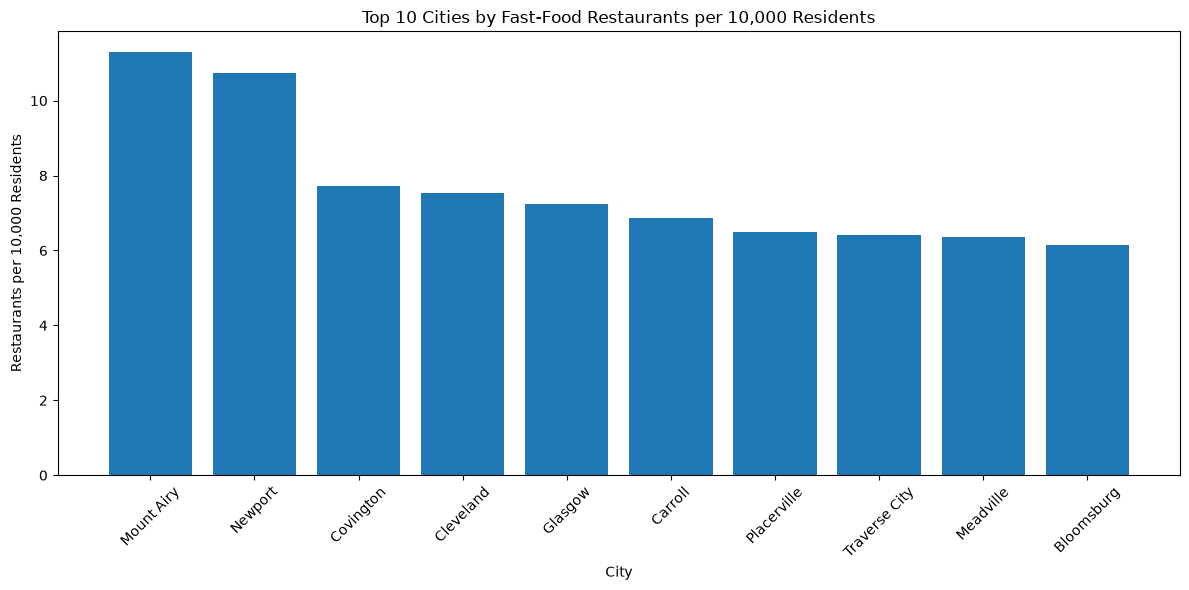

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    top10_filtered["city"],
    top10_filtered["restaurants_per_10000"]
)

plt.title("Top 10 Cities by Fast-Food Restaurants per 10,000 Residents")
plt.xlabel("City")
plt.ylabel("Restaurants per 10,000 Residents")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("question8_chart.png", dpi=300)

plt.show()

In [15]:
top10_filtered.to_csv("question8_top10.csv", index=False)

# Question 8: Number of Fast-Food Restaurants per Capita

## Objective
To determine the number of fast-food restaurants per capita across cities in the United States.

## Methodology
Restaurant counts were grouped by city and merged with city population data. The number of fast-food restaurants per 10,000 residents was calculated using the following formula:

Restaurants per 10,000 Residents = (Restaurant Count / Population) × 10,000

To avoid extremely small towns dominating the results, cities with populations below 10,000 were excluded from the ranking.

## Summary Statistics

- Number of cities analyzed: 3,051
- Average restaurants per 10,000 residents: 2.43
- Minimum: 0.009
- Maximum: 91.74

## Top Cities

| Rank | City | State | Restaurants per 10,000 |
|------|-------|--------|-------------------------|
| 1 | Mount Airy | North Carolina | 11.29 |
| 2 | Newport | Kentucky | 10.74 |
| 3 | Covington | Louisiana | 7.72 |
| 4 | Cleveland | Mississippi | 7.53 |
| 5 | Glasgow | Kentucky | 7.24 |

## Conclusion

The average number of fast-food restaurants was approximately **2.43 per 10,000 residents** across the analyzed cities. Mount Airy (North Carolina) had the highest restaurant density among cities with populations of at least 10,000, followed by Newport (Kentucky). This suggests that restaurant density varies considerably between cities and is not determined solely by population size.

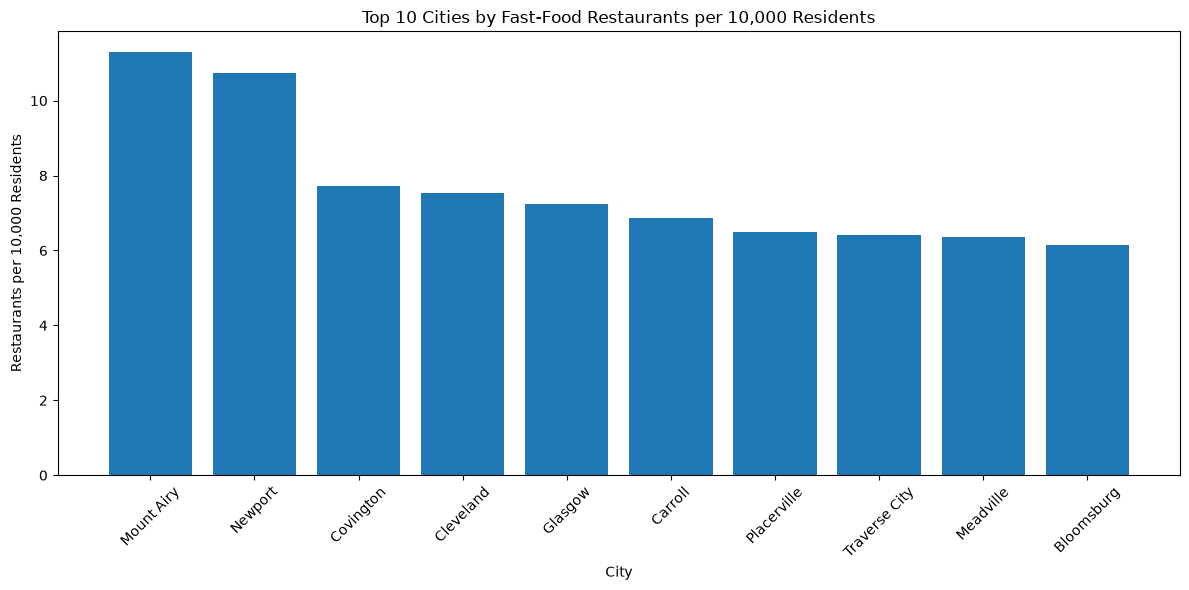

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    top10_filtered["city"],
    top10_filtered["restaurants_per_10000"]
)

plt.title("Top 10 Cities by Fast-Food Restaurants per 10,000 Residents")
plt.xlabel("City")
plt.ylabel("Restaurants per 10,000 Residents")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("question8_chart.png", dpi=300)

plt.show()